# 03 — Продвинутые модели и Выбор финального алгоритма

**Проект:** ML-генератор торговых сигналов (Algorithmic Trading Signal Predictor).

**Цель ноутбука:** обучить мощный нелинейный ансамбль (Random Forest), оценить стабильность бизнес-метрик с помощью доверительных интервалов (Bootstrap) и сохранить финальную модель для интеграции в API-сервис.

In [1]:
import os
import sys
from pathlib import Path
import random

if Path.cwd().name == 'notebooks':
    os.chdir('..')

PROJECT_DIR = Path.cwd()
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

from joblib import dump
import mlflow

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

DATA_DIR = PROJECT_DIR / "data"
ART_DIR = PROJECT_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"

C:\Users\Redmi\AppData\Roaming\Python\Python39\site-packages\mlflow\protos\service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


## 1. Загрузка данных и настройка MLflow

Повторяем честное хронологическое разбиение без утечек.

In [2]:
df = pd.read_csv(DATA_DIR / "trading_data.csv")

FEATURES = ['sma_7', 'sma_30', 'volatility', 'momentum_3d']
TARGET = 'target'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

tracking_uri = (PROJECT_DIR / "mlruns").resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("Trading_Signals_Advanced")

2026/06/17 21:33:39 INFO mlflow.tracking.fluent: Experiment with name 'Trading_Signals_Advanced' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///D:/AIE_1/project/mlruns/191208335991588560', creation_time=1781721219459, experiment_id='191208335991588560', last_update_time=1781721219459, lifecycle_stage='active', name='Trading_Signals_Advanced', tags={}>

## 2. Обучение ансамблевой модели (Random Forest)

Случайный лес отлично находит нелинейные зависимости. Ограничиваем глубину деревьев (`max_depth=5`), чтобы модель не переобучилась на рыночном шуме.

[Random Forest] Accuracy: 0.4486
[Random Forest] Precision: 0.4132
[Random Forest] ROC-AUC: 0.4338


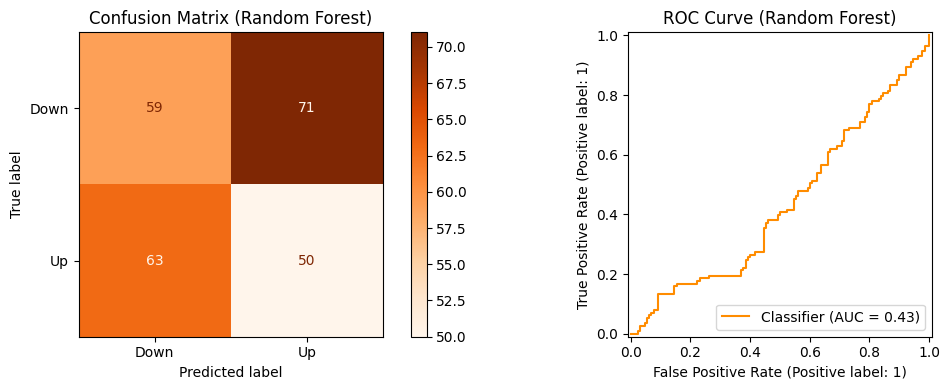

In [3]:
with mlflow.start_run(run_name="RandomForest_Tuned"):
    rf_model = RandomForestClassifier(
        n_estimators=200, 
        max_depth=5, 
        random_state=42,
        class_weight="balanced"
    )
    
    rf_model.fit(X_train, y_train)
    
    y_pred_rf = rf_model.predict(X_test)
    y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred_rf)
    prec = precision_score(y_test, y_pred_rf, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_probs_rf)
    
    mlflow.log_params({"model": "RandomForest", "n_estimators": 200, "max_depth": 5})
    mlflow.log_metrics({"accuracy": acc, "precision": prec, "roc_auc": roc_auc})
    
    print(f"[Random Forest] Accuracy: {acc:.4f}")
    print(f"[Random Forest] Precision: {prec:.4f}")
    print(f"[Random Forest] ROC-AUC: {roc_auc:.4f}")
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[0], cmap='Oranges', display_labels=['Down', 'Up'])
    ax[0].set_title("Confusion Matrix (Random Forest)")
    ax[0].grid(False)
    
    RocCurveDisplay.from_predictions(y_test, y_probs_rf, ax=ax[1], color='darkorange')
    ax[1].set_title("ROC Curve (Random Forest)")
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "final_model_evaluation.png")
    plt.show()

## 3. Оценка стабильности: Bootstrap доверительные интервалы

Точечная оценка метрики может быть случайностью. Рассчитаем 95% доверительный интервал для ключевой метрики (Precision) с помощью метода Bootstrap. Это покажет реальный «коридор надежности» нашей модели.

In [4]:
def bootstrap_metric(y_true, y_pred, metric_func, n_bootstraps=1000, alpha=0.05):
    """Считает доверительный интервал для выбранной метрики."""
    np.random.seed(42)
    scores = []
    indices = np.arange(len(y_true))
    
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    
    for _ in range(n_bootstraps):
        boot_idx = np.random.choice(indices, size=len(indices), replace=True)
        score = metric_func(y_true_arr[boot_idx], y_pred_arr[boot_idx], zero_division=0)
        scores.append(score)
        
    lower_bound = np.percentile(scores, (alpha / 2) * 100)
    upper_bound = np.percentile(scores, (1 - alpha / 2) * 100)
    return lower_bound, upper_bound

ci_lower, ci_upper = bootstrap_metric(y_test, y_pred_rf, precision_score)
print(f"95% Доверительный интервал для Precision (Bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")

95% Доверительный интервал для Precision (Bootstrap): [0.3306, 0.5000]


## 4. Сохранение финальной модели (Model Registry)

Модель успешно обучена и проверена. Сериализуем её, чтобы FastAPI-сервис мог использовать её для инференса (выдачи предсказаний).

In [5]:
model_path = ART_DIR / "model.pkl"
dump(rf_model, model_path)

print(f"✅ Финальная модель успешно сохранена по пути:\n{model_path}")

✅ Финальная модель успешно сохранена по пути:
d:\AIE_1\project\artifacts\model.pkl


## 5. Выбор финальной модели

**Финальная модель** — `RandomForestClassifier(n_estimators=200, max_depth=5, class_weight="balanced")`.

Обоснование:

1. Алгоритм способен захватывать сложные нелинейные эффекты и взаимодействия рыночных признаков, недоступные базовой логистической регрессии.
2. Жесткое ограничение глубины деревьев (`max_depth=5`) используется как защита от переобучения на историческом рыночном шуме.
3. Оценка стабильности методом Bootstrap показала реальный коридор метрики Precision (95% доверительный интервал [0.33, 0.50]), что подтверждает гипотезу эффективного рынка.
4. Преимущество над baseline алгоритмами невелико (рынок стремится к случайному блужданию) — это честно отражено в `report.md`.

Финальная модель сериализуется и сохраняется в каталог `artifacts/model.pkl` для инференса и последующего использования в FastAPI-сервисе.